**NTI Final Project Crop Classification**


---
Team Members:

* Huthyfa Moamen Marei (حذيفة مؤمن مرعي)
* Mohamed Alaaeldin Ragab Allam (محمد علاء الدين رجب علام)
* Serag elden Mohamed Samir Ahmed (سراج الدين محمد سمير أحمد)








In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [35]:
data =pd.read_csv('Crop_recommendation.csv')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [36]:
data.shape

(2200, 8)

In [37]:
data.isna().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [38]:
data.duplicated().sum()

np.int64(0)

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [40]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


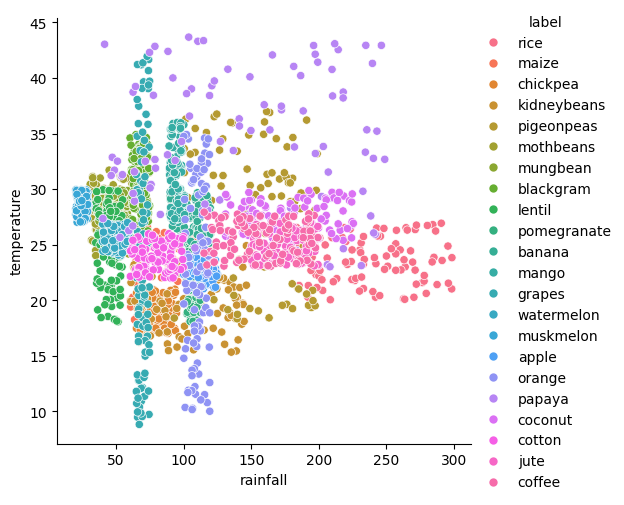

In [41]:
sns.relplot(x='rainfall',y='temperature',data=data,hue='label',height=5)
plt.show()

In [42]:
x =data.drop(['label'], axis=1)
y =data['label']
encode = LabelEncoder()
y = encode.fit_transform(y)


In [43]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)
print(len(x_train), len(x_test))
print(len(y_train), len(y_test))

1760 440
1760 440


# Decision Tree Classifier

In [44]:
tree = DecisionTreeClassifier(criterion="entropy",random_state=0)
tree.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [45]:
y_tree_pred = tree.predict(x_test)
tree_accuracy = accuracy_score(y_test,y_tree_pred)
tree_f1 = f1_score(y_test,y_tree_pred,average='weighted')

print("Train score",tree.score(x_train,y_train))
print("Test score",tree.score(x_test,y_test))
print("Tree accuracy:",tree_accuracy)
print("Tree F1 score:",tree_f1)




Train score 1.0
Test score 0.990909090909091
Tree accuracy: 0.990909090909091
Tree F1 score: 0.9910028561554725


In [46]:
# التقرير ده هيطبعلك كل محصول الموديل جاب فيه دقة كام في المية
tree_report = classification_report(y_test, y_tree_pred, target_names=encode.classes_)
print(tree_report)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       1.00      0.95      0.98        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      0.88      0.94        17
      cotton       1.00      1.00      1.00        16
      grapes       1.00      1.00      1.00        18
        jute       1.00      1.00      1.00        21
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        17
       maize       0.86      1.00      0.92        18
       mango       1.00      1.00      1.00        21
   mothbeans       0.96      0.96      0.96        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00        23
      papaya       1.00    

# Random Forest Classifier

In [47]:
rfc = RandomForestClassifier(n_estimators=10,max_depth=4,random_state=42)
rfc.fit(x_train,y_train)

RandomForestClassifier(max_depth=4, n_estimators=10, random_state=42)

In [48]:
y_rfc_pred = rfc.predict(x_test)
rfc_accuracy = accuracy_score(y_test,y_rfc_pred)
rfc_f1 = f1_score(y_test,y_tree_pred,average='weighted')

print("Train Score",rfc.score(x_train,y_train))
print("Test Score",rfc.score(x_test,y_test))
print("RFC Accuracy:",rfc_accuracy)
print("RFC F1 Score:",rfc_f1)


Train Score 0.9267045454545455
Test Score 0.9090909090909091
RFC Accuracy: 0.9090909090909091
RFC F1 Score: 0.9910028561554725


In [49]:
# التقرير ده هيطبعلك كل محصول الموديل جاب فيه دقة كام في المية
rfc_report = classification_report(y_test, y_rfc_pred, target_names=encode.classes_)
print(rfc_report)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       0.48      0.95      0.64        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       0.94      1.00      0.97        17
      cotton       0.94      0.94      0.94        16
      grapes       1.00      1.00      1.00        18
        jute       0.86      0.90      0.88        21
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.59      0.59      0.59        17
       maize       0.89      0.94      0.92        18
       mango       0.88      1.00      0.93        21
   mothbeans       0.00      0.00      0.00        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00        23
      papaya       1.00    

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Support Vector Machine (SVM)

In [50]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [51]:
svm = SVC(kernel='rbf', random_state=0)
svm.fit(x_train_scaled, y_train)

y_svm_pred = svm.predict(x_test_scaled)

svm_accuracy = accuracy_score(y_test, y_svm_pred)
svm_f1 = f1_score(y_test, y_svm_pred, average='weighted')

print("Train Score", svm.score(x_train_scaled, y_train))
print("Test Score", svm.score(x_test_scaled, y_test))
print("SVM Accuracy:", svm_accuracy)
print("SVM F1 Score:", svm_f1)

Train Score 0.9875
Test Score 0.9772727272727273
SVM Accuracy: 0.9772727272727273
SVM F1 Score: 0.977320095274435


In [52]:
svm_report = classification_report(y_test, y_svm_pred, target_names=encode.classes_)
print(svm_report)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       1.00      0.95      0.98        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        16
      grapes       1.00      1.00      1.00        18
        jute       0.81      1.00      0.89        21
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.89      0.94      0.91        17
       maize       1.00      0.94      0.97        18
       mango       1.00      1.00      1.00        21
   mothbeans       0.96      0.96      0.96        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00        23
      papaya       1.00    

#XGBoost

In [53]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(x_train, y_train)
y_xgb_pred = xgb_model.predict(x_test)


In [54]:
xgb_accuracy = accuracy_score(y_test, y_xgb_pred)
xgb_f1 = f1_score(y_test, y_xgb_pred, average='weighted')

print("Train score", xgb_model.score(x_train, y_train))
print("Test score", xgb_model.score(x_test, y_test))
print("XGBoost accuracy:", xgb_accuracy)
print("XGBoost F1 score:", xgb_f1)


Train score 1.0
Test score 0.9931818181818182
XGBoost accuracy: 0.9931818181818182
XGBoost F1 score: 0.9931655191386568


In [55]:

xgb_report = classification_report(y_test, y_xgb_pred, target_names=encode.classes_)
print(xgb_report)



              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       1.00      1.00      1.00        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        16
      grapes       1.00      1.00      1.00        18
        jute       1.00      0.95      0.98        21
 kidneybeans       0.95      1.00      0.98        20
      lentil       1.00      0.94      0.97        17
       maize       1.00      1.00      1.00        18
       mango       1.00      1.00      1.00        21
   mothbeans       0.96      1.00      0.98        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00        23
      papaya       1.00    

# Confusion Matrix

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(16, 12))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encode.classes_,
                yticklabels=encode.classes_)

    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('(True Crop)', fontsize=14)
    plt.xlabel('(Predicted Crop)', fontsize=14)

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


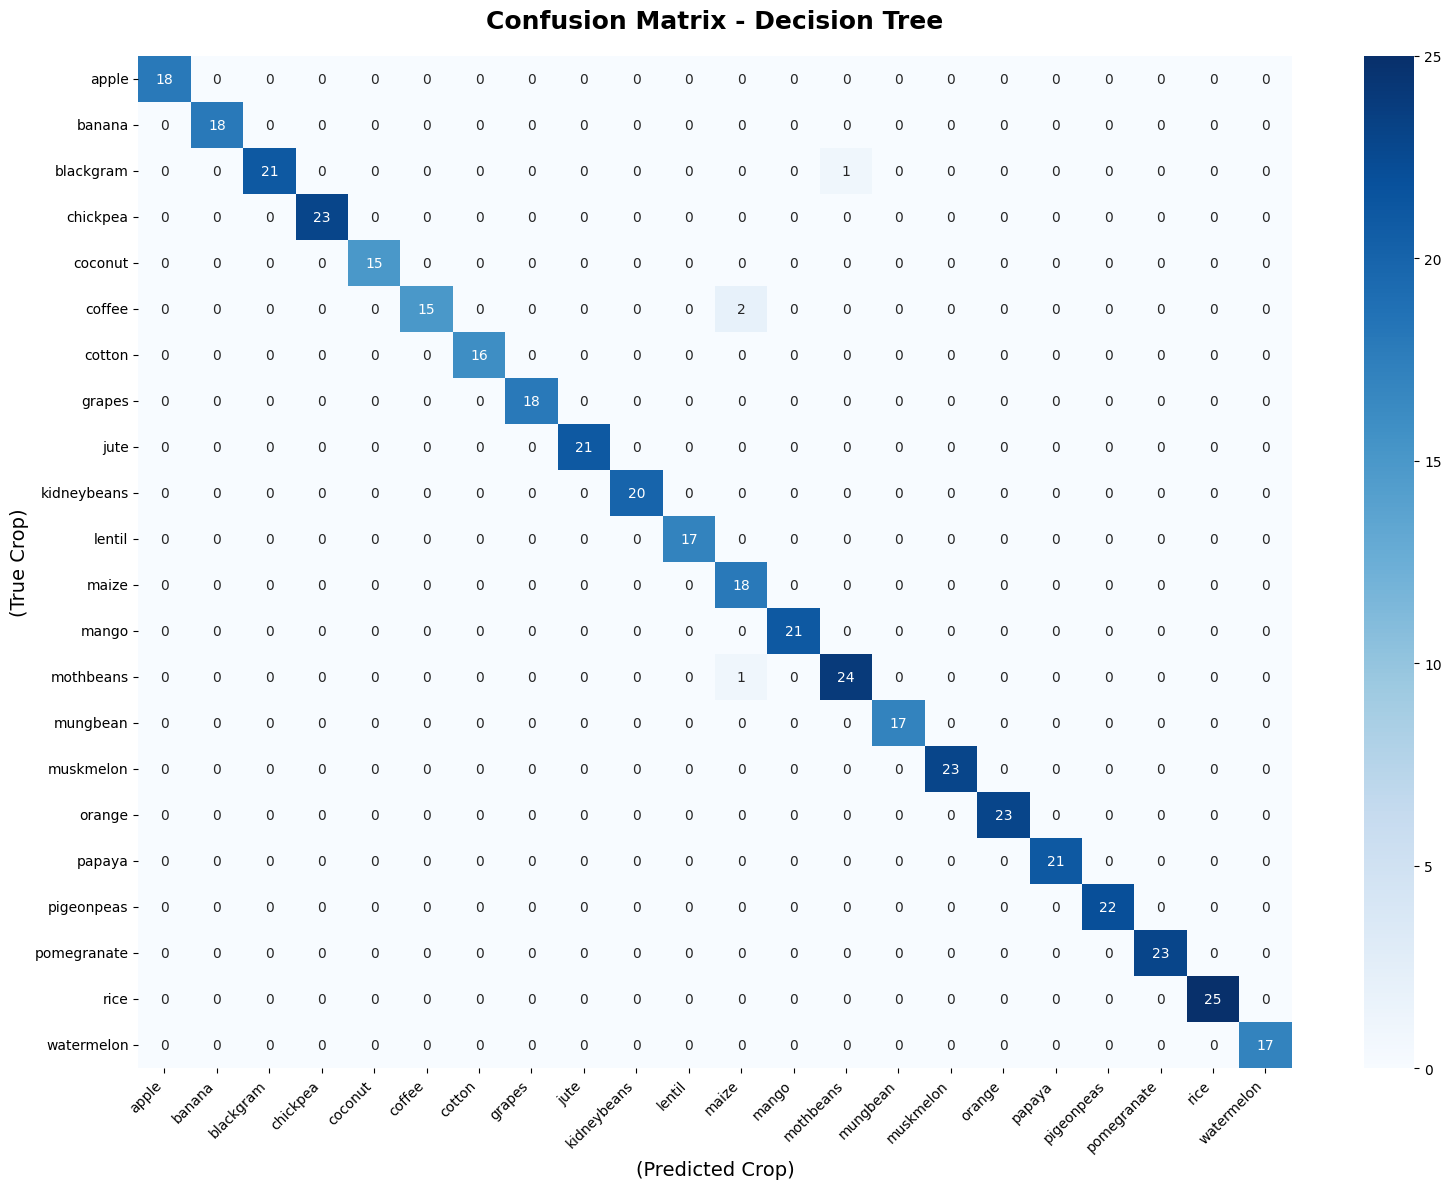

In [57]:
plot_confusion_matrix(y_test, y_tree_pred, 'Confusion Matrix - Decision Tree')


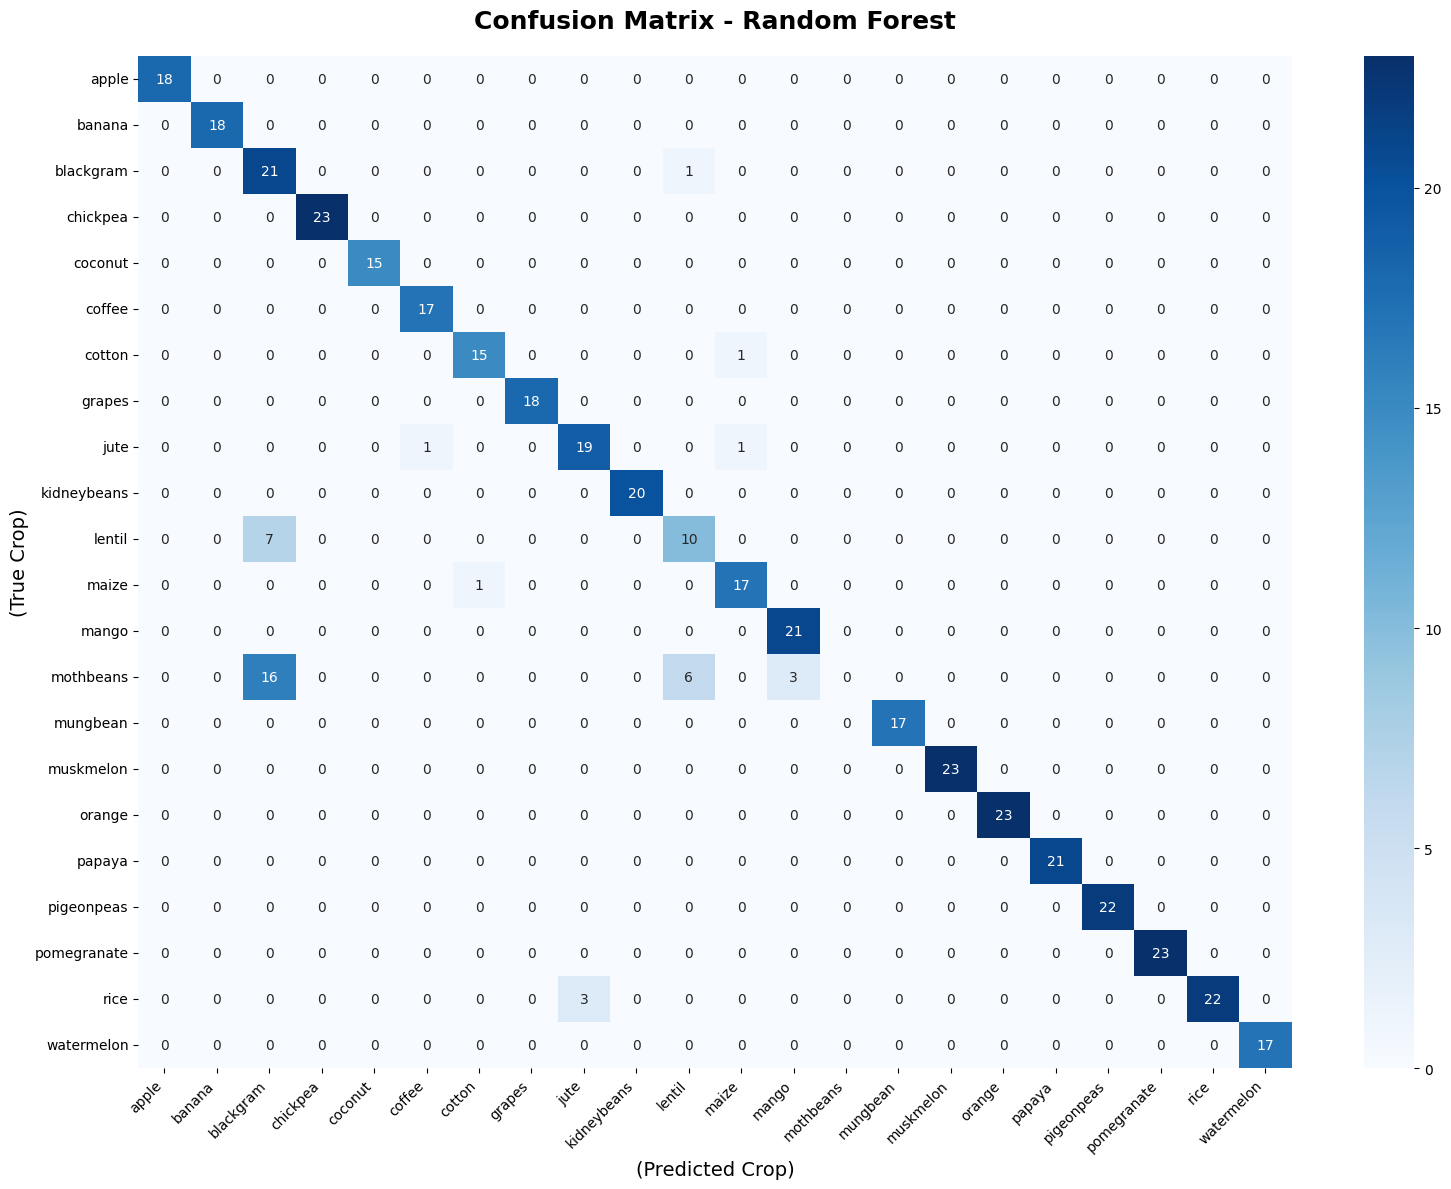

In [58]:
plot_confusion_matrix(y_test, y_rfc_pred, 'Confusion Matrix - Random Forest')



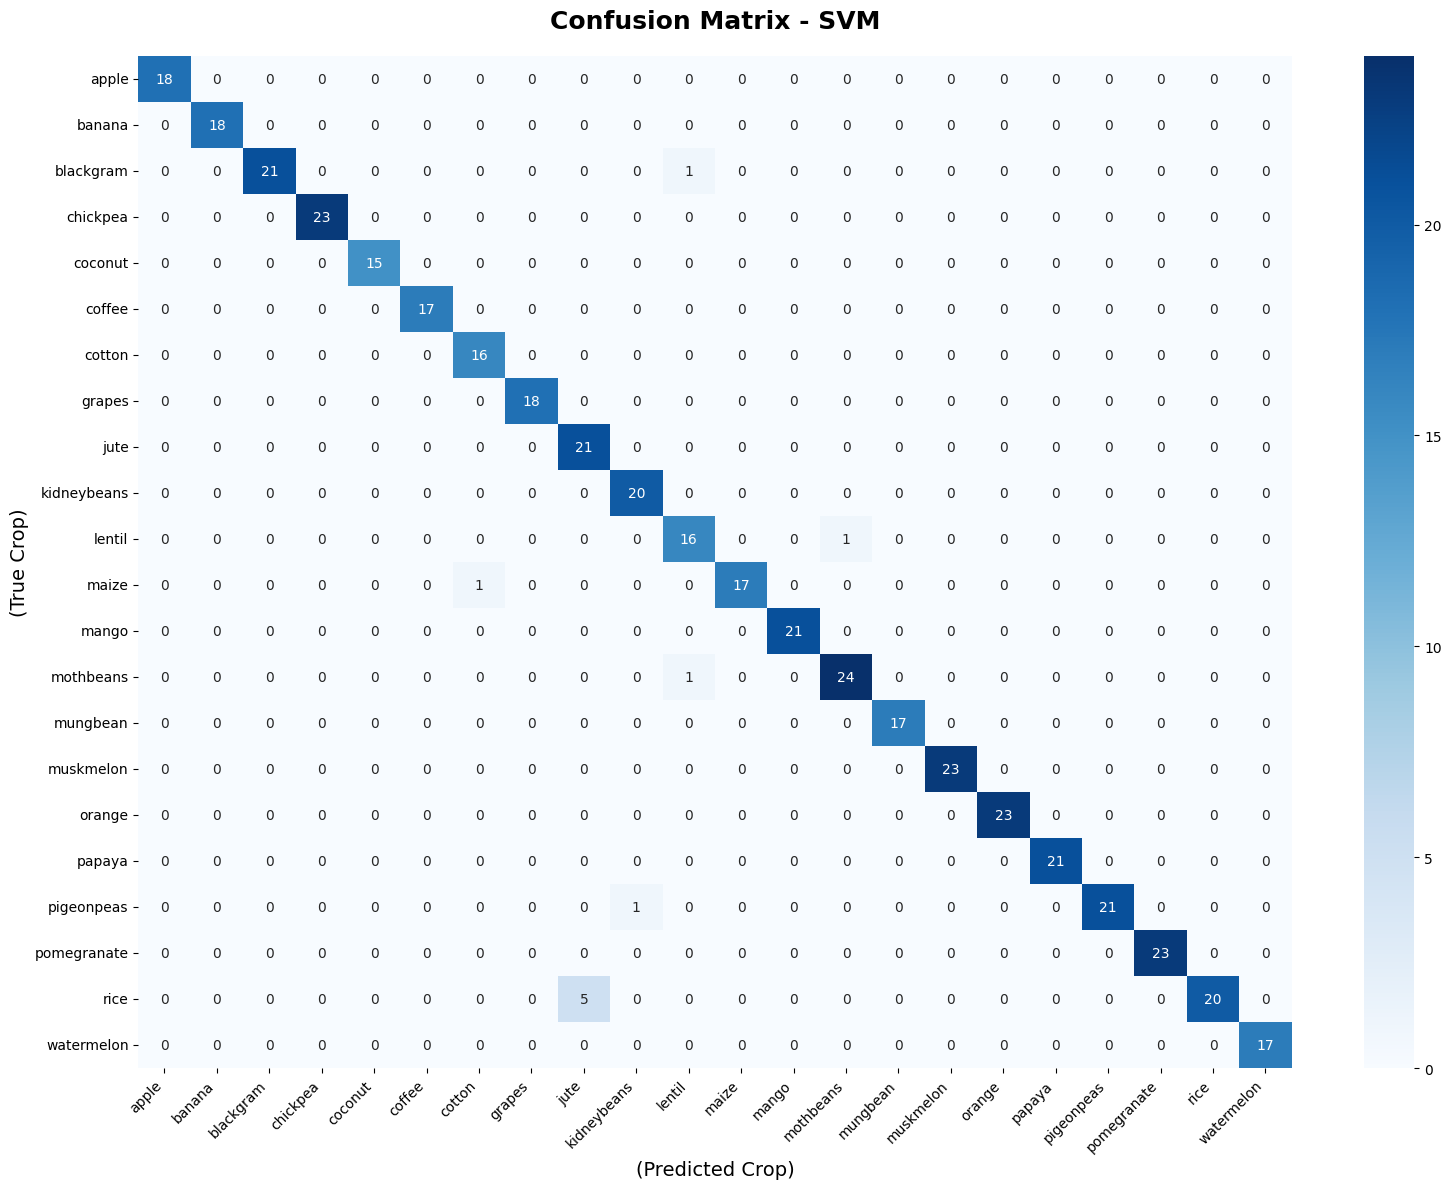

In [59]:
plot_confusion_matrix(y_test, y_svm_pred, 'Confusion Matrix - SVM')

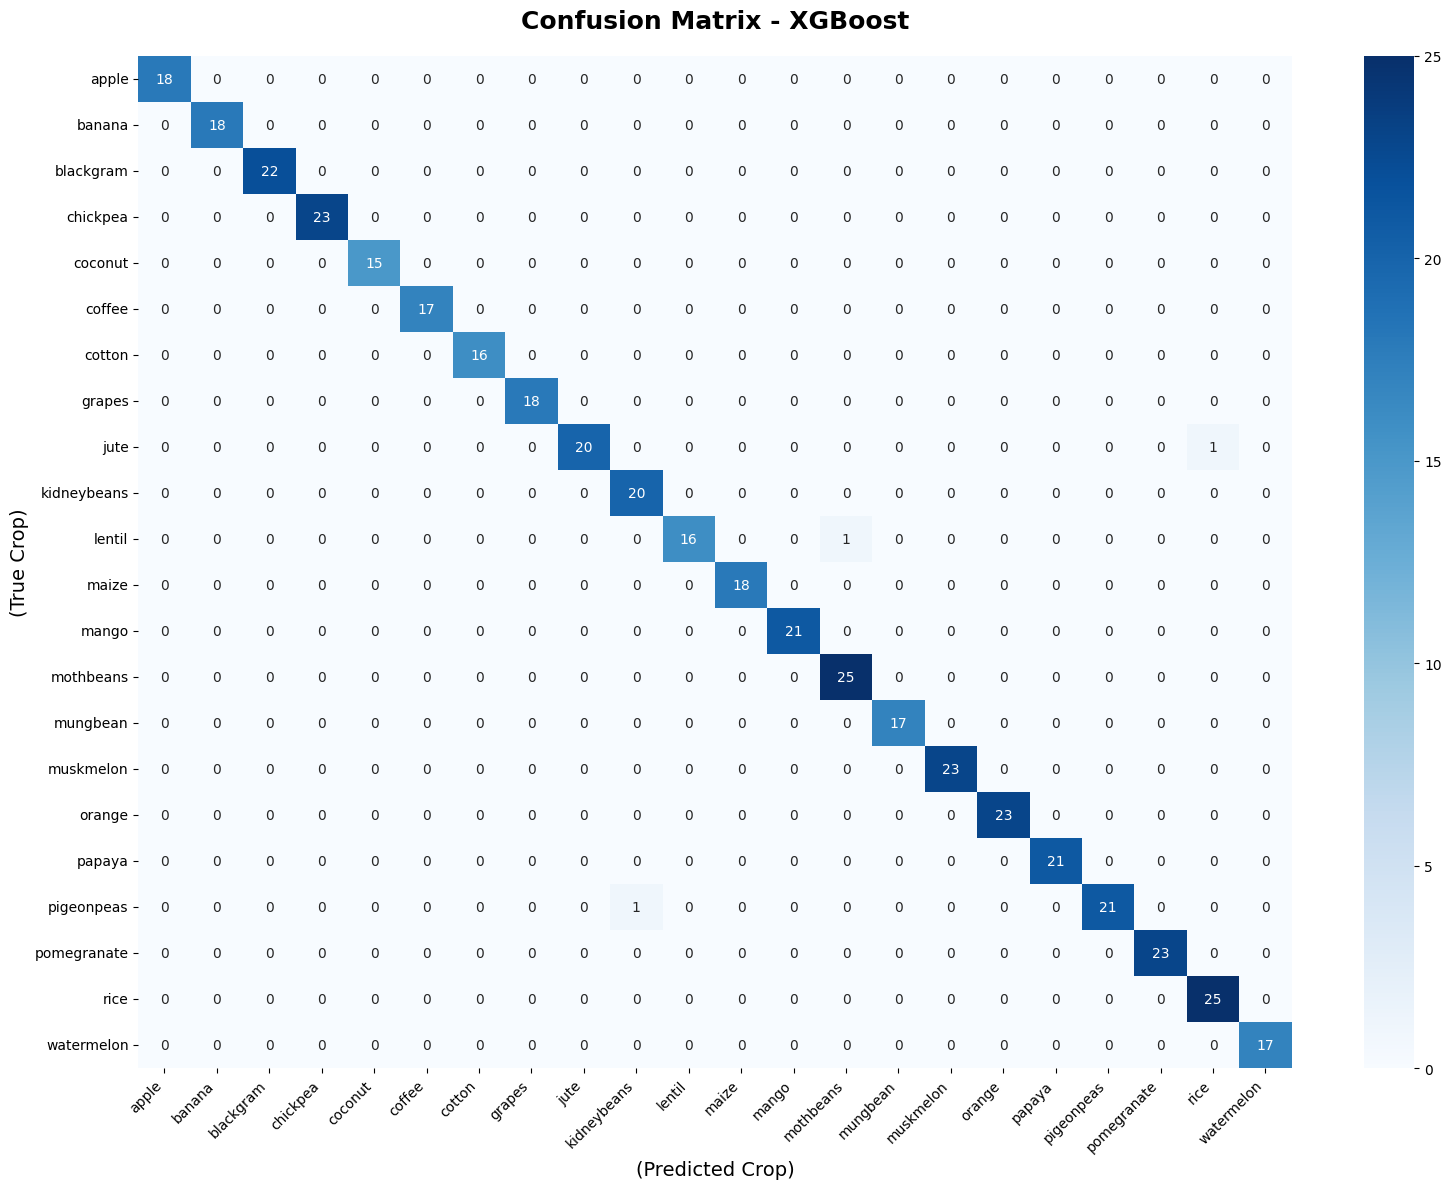

In [60]:
plot_confusion_matrix(y_test, y_xgb_pred, 'Confusion Matrix - XGBoost')

# Results & Error Analysis

In [61]:
from IPython.display import display

# 1. Decode numeric labels back to crop names for all models
actual_crops = encode.inverse_transform(y_test)
rf_predicted_crops = encode.inverse_transform(y_rfc_pred)
svm_predicted_crops = encode.inverse_transform(y_svm_pred)
xgb_predicted_crops = encode.inverse_transform(y_xgb_pred) # ضفنا تحويل الـ XGBoost

# 2. Create a combined DataFrame for Error Analysis
error_analysis_df = x_test.copy()
error_analysis_df['Actual Crop'] = actual_crops
error_analysis_df['RF Predicted'] = rf_predicted_crops
error_analysis_df['SVM Predicted'] = svm_predicted_crops
error_analysis_df['XGB Predicted'] = xgb_predicted_crops # ضفنا عمود الـ XGBoost

# 3. Filter instances where AT LEAST ONE model made a mistake
wrong_predictions = error_analysis_df[
    (error_analysis_df['Actual Crop'] != error_analysis_df['RF Predicted']) |
    (error_analysis_df['Actual Crop'] != error_analysis_df['SVM Predicted']) |
    (error_analysis_df['Actual Crop'] != error_analysis_df['XGB Predicted']) # ضفنا شرط الـ XGBoost
]

# 4. Print the error analysis report
print("-" * 80)
print(f"🎯 Found {len(wrong_predictions)} cases where at least one model made an incorrect prediction.")
print("-" * 80)
print("=== Error Analysis Table (Misclassified Instances) ===")

display(wrong_predictions)

--------------------------------------------------------------------------------
🎯 Found 47 cases where at least one model made an incorrect prediction.
--------------------------------------------------------------------------------
=== Error Analysis Table (Misclassified Instances) ===


,N,P,K,temperature,humidity,ph,rainfall,Actual Crop,RF Predicted,SVM Predicted,XGB Predicted
70,61,52,41,24.976695,83.891805,6.880431,204.800185,rice,rice,jute,rice
565,11,41,19,26.859113,41.814208,5.131779,44.138271,mothbeans,lentil,mothbeans,mothbeans
546,25,51,18,27.777995,54.821308,9.459493,50.284387,mothbeans,blackgram,mothbeans,mothbeans
2098,90,39,43,24.447439,82.286484,6.769346,190.968489,jute,jute,jute,rice
536,6,36,22,24.216103,59.792363,8.869533,42.247835,mothbeans,mango,mothbeans,mothbeans
563,28,57,17,30.477577,61.582453,9.416003,61.866339,mothbeans,blackgram,mothbeans,mothbeans
512,27,43,23,31.704475,56.854201,5.875334,44.943174,mothbeans,blackgram,mothbeans,mothbeans
883,14,76,20,29.059412,62.106524,7.042475,36.501137,lentil,blackgram,lentil,lentil
135,98,44,21,25.771751,74.089114,6.524478,107.493192,maize,cotton,cotton,maize
517,0,55,25,28.174894,43.667230,4.524172,45.781728,mothbeans,blackgram,mothbeans,mothbeans


In [62]:
def predict_my_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_features = [[N, P, K, temperature, humidity, ph, rainfall]]

    predicted_num = rfc.predict(input_features)

    crop_name = encode.inverse_transform(predicted_num)[0]

    print("-" * 60)
    print(f"🌾 Based on the soil and climate conditions,")
    print(f"   the most suitable crop to grow is: {crop_name.upper()}")
    print("-" * 60)

predict_my_crop(N = 90, P = 42, K = 43, temperature = 20.8, humidity = 82.0, ph = 6.5, rainfall = 202.9)

------------------------------------------------------------
🌾 Based on the soil and climate conditions,
   the most suitable crop to grow is: RICE
------------------------------------------------------------


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Website

In [63]:
import joblib

joblib.dump(rfc, 'crop_model.pkl')
joblib.dump(encode, 'label_encoder.pkl')

['label_encoder.pkl']